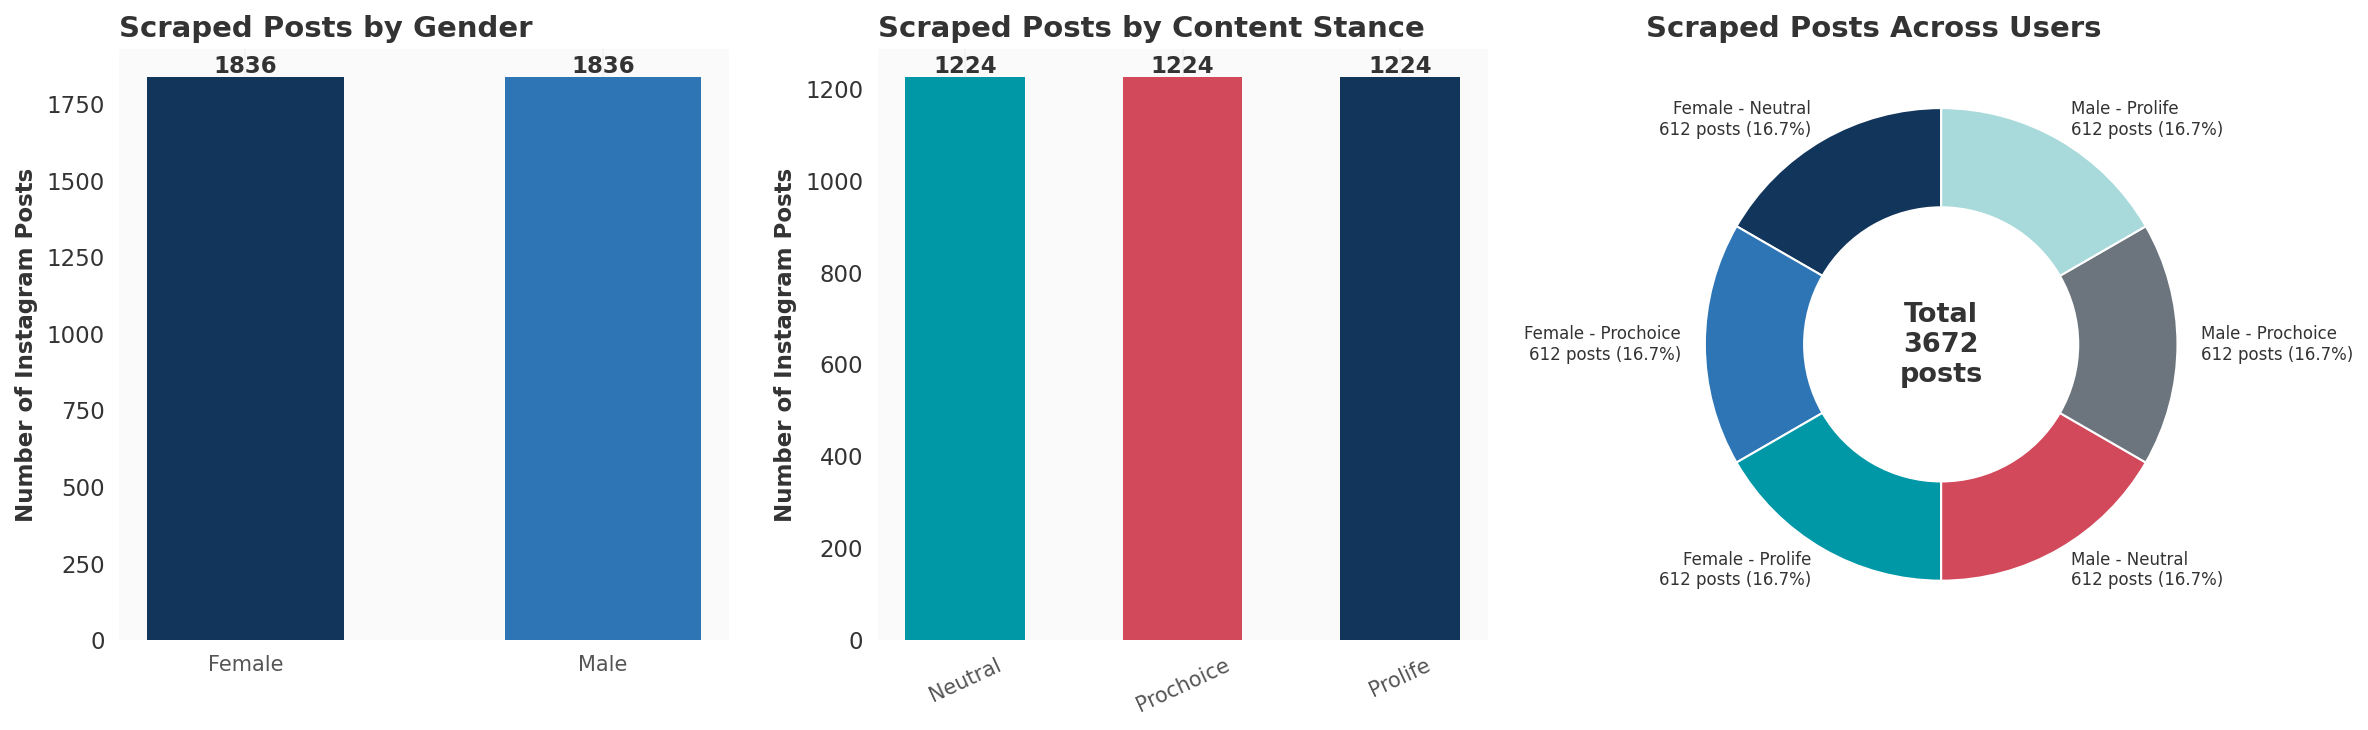

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# =============================
# Clean scientific style
# =============================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white"
})


# =============================
# Dataset
# =============================
base = Path("/Users/shergoshami/Downloads/DATA")

users = [
    "female_neutral",
    "female_prochoice",
    "female_prolife",
    "male_neutral",
    "male_prochoice",
    "male_prolife"
]


data = []

for user in users:

    folder = base / user

    if folder.exists():

        gender, stance = user.split("_", 1)

        post_count = sum(
            f.is_file() and not f.name.startswith(".")
            for f in folder.iterdir()
        )

        data.append({
            "User_Section": user,
            "Gender": gender.capitalize(),
            "Stance": stance.replace("_", " ").capitalize(),
            "Posts": post_count
        })


df = pd.DataFrame(data)


if df.empty:
    raise ValueError("No dataset folders found.")


# =============================
# Colors
# =============================
navy = "#12355B"
blue = "#2E75B6"

teal = "#0097A7"
red = "#D1495B"
gray = "#6C757D"
light_blue = "#A8DADC"

gender_colors = [
    navy,
    blue
]

stance_colors = [
    teal,
    red,
    navy
]

pie_colors = [
    navy,
    blue,
    teal,
    red,
    gray,
    light_blue
]


# =============================
# Figure
# =============================
fig, ax = plt.subplots(
    1,
    3,
    figsize=(16,5),
    dpi=150
)


# =============================
# Posts by Gender
# =============================
gender_posts = (
    df.groupby("Gender")["Posts"]
    .sum()
)


bars = ax[0].bar(
    gender_posts.index,
    gender_posts.values,
    color=gender_colors,
    width=0.55
)


ax[0].set_title(
    "Scraped Posts by Gender",
    loc="left",
    fontweight="bold"
)

ax[0].set_ylabel(
    "Number of Instagram Posts"
)


for bar in bars:
    ax[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# =============================
# Posts by Stance
# =============================
stance_posts = (
    df.groupby("Stance")["Posts"]
    .sum()
)


bars = ax[1].bar(
    stance_posts.index,
    stance_posts.values,
    color=stance_colors[:len(stance_posts)],
    width=0.55
)


ax[1].set_title(
    "Scraped Posts by Content Stance",
    loc="left",
    fontweight="bold"
)

ax[1].set_ylabel(
    "Number of Instagram Posts"
)

ax[1].tick_params(
    axis="x",
    rotation=25
)


for bar in bars:
    ax[1].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# =============================
# User section distribution
# =============================
donut_values = df["Posts"]

labels = (
    df["Gender"]
    + " - "
    + df["Stance"]
)


total_posts = donut_values.sum()


donut_labels = []

for i in range(len(df)):

    value = donut_values.iloc[i]
    percentage = value / total_posts * 100

    donut_labels.append(
        f"{labels.iloc[i]}\n{value} posts ({percentage:.1f}%)"
    )


ax[2].pie(
    donut_values,
    labels=donut_labels,
    colors=pie_colors[:len(df)],
    startangle=90,
    wedgeprops={
        "width":0.42,
        "edgecolor":"white"
    },
    textprops={
        "fontsize":8
    }
)


ax[2].text(
    0,
    0,
    f"Total\n{total_posts}\nposts",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)


ax[2].set_title(
    "Scraped Posts Across Users",
    loc="left",
    fontweight="bold"
)


# =============================
# Formatting
# =============================
for a in ax:
    a.set_axisbelow(True)
    a.grid(axis="y")
    a.tick_params(
        bottom=False,
        left=False
    )


plt.tight_layout()

plt.show()

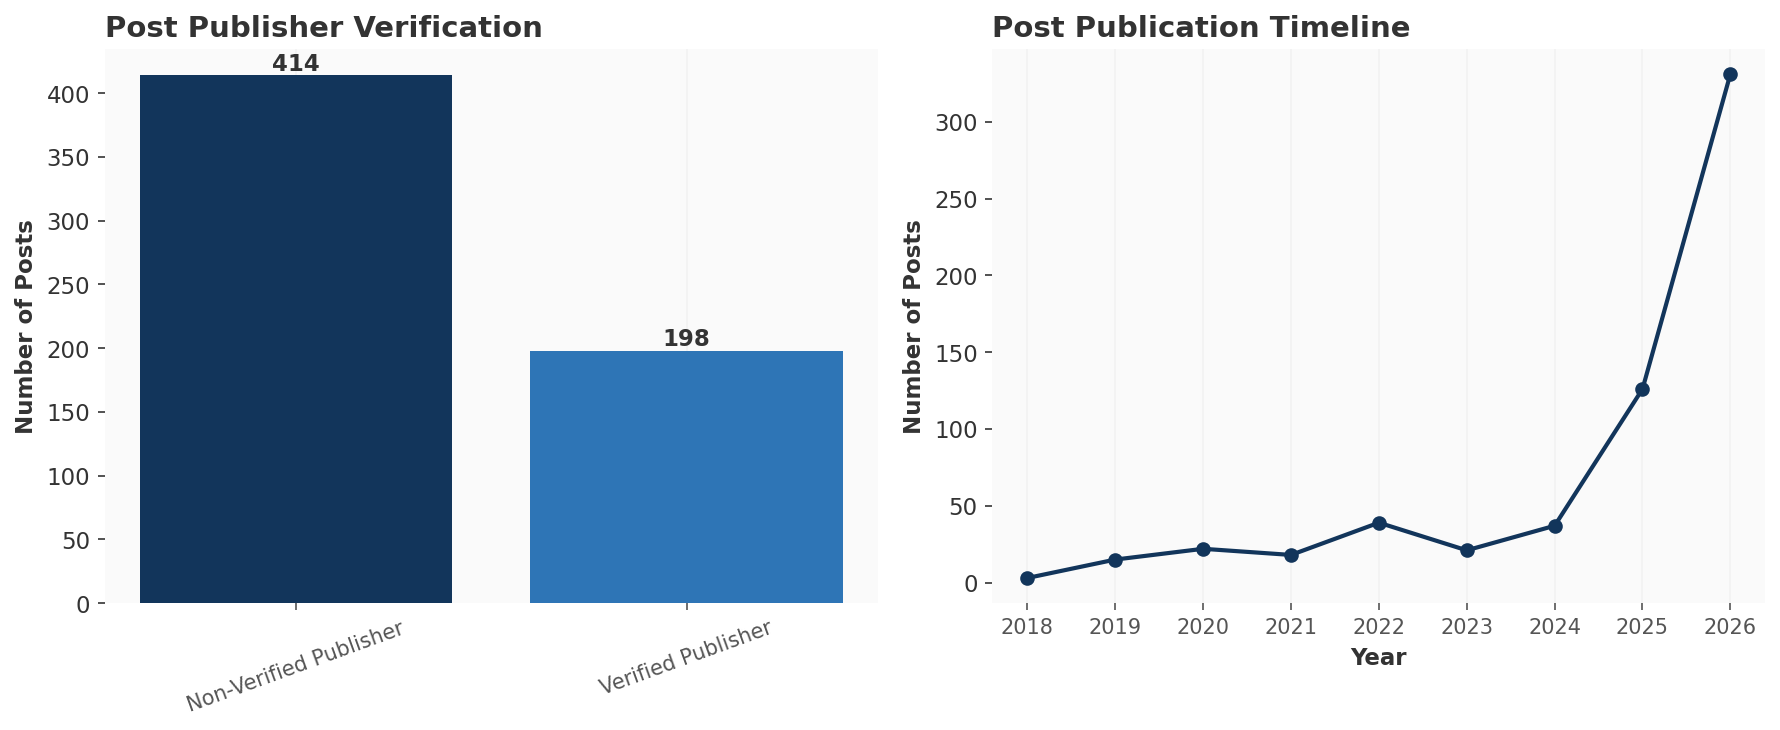


POST PUBLISHER VERIFICATION
Post_Verified
Non-Verified Publisher    414
Verified Publisher        198
Name: count, dtype: int64

POSTS BY PUBLICATION YEAR
Year
2018      3
2019     15
2020     22
2021     18
2022     39
2023     21
2024     37
2025    126
2026    331
Name: count, dtype: int64


In [12]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


# =============================
# Scientific style
# =============================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.facecolor": "white"
})


# =============================
# Dataset
# =============================
base = Path("/Users/shergoshami/Downloads/DATA")


# Only post-level source needed
post_source = base / "male_prolife"


# =============================
# Extract post data
# =============================

posts = []


for file in post_source.glob("*.json"):

    with open(file, "r") as f:
        post = json.load(f)


    posts.append({

        "Timestamp": post.get(
            "post_timestamp",
            None
        ),

        "Post_Verified": post.get(
            "post_publisher_is_verified",
            False
        )
    })


posts_df = pd.DataFrame(posts)



# =============================
# Timestamp processing
# =============================

posts_df["Timestamp"] = pd.to_datetime(
    posts_df["Timestamp"]
)


posts_df["Year"] = (
    posts_df["Timestamp"]
    .dt.year
)



# =============================
# Colors
# =============================

navy = "#12355B"
blue = "#2E75B6"



# =============================
# Figure
# =============================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5),
    dpi=150
)



# ==================================================
# Post publisher verification
# ==================================================

publisher_status = (
    posts_df["Post_Verified"]
    .value_counts()
    .rename({
        True: "Verified Publisher",
        False: "Non-Verified Publisher"
    })
)


bars = ax[0].bar(
    publisher_status.index,
    publisher_status.values,
    color=[
        navy,
        blue
    ]
)


ax[0].set_title(
    "Post Publisher Verification",
    loc="left",
    fontweight="bold"
)


ax[0].set_ylabel(
    "Number of Posts"
)


ax[0].tick_params(
    axis="x",
    rotation=20
)


for bar in bars:

    ax[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )



# ==================================================
# Publication timeline
# ==================================================

year_distribution = (
    posts_df["Year"]
    .value_counts()
    .sort_index()
)


ax[1].plot(
    year_distribution.index,
    year_distribution.values,
    marker="o",
    color=navy,
    linewidth=2
)


ax[1].set_title(
    "Post Publication Timeline",
    loc="left",
    fontweight="bold"
)


ax[1].set_xlabel(
    "Year"
)


ax[1].set_ylabel(
    "Number of Posts"
)



# =============================
# Formatting
# =============================

for a in ax:
    a.set_axisbelow(True)
    a.grid(axis="y")


plt.tight_layout()

plt.show()



# =============================
# Statistical summaries
# =============================

print("\nPOST PUBLISHER VERIFICATION")
print(
    publisher_status
)


print("\nPOSTS BY PUBLICATION YEAR")
print(
    year_distribution
)

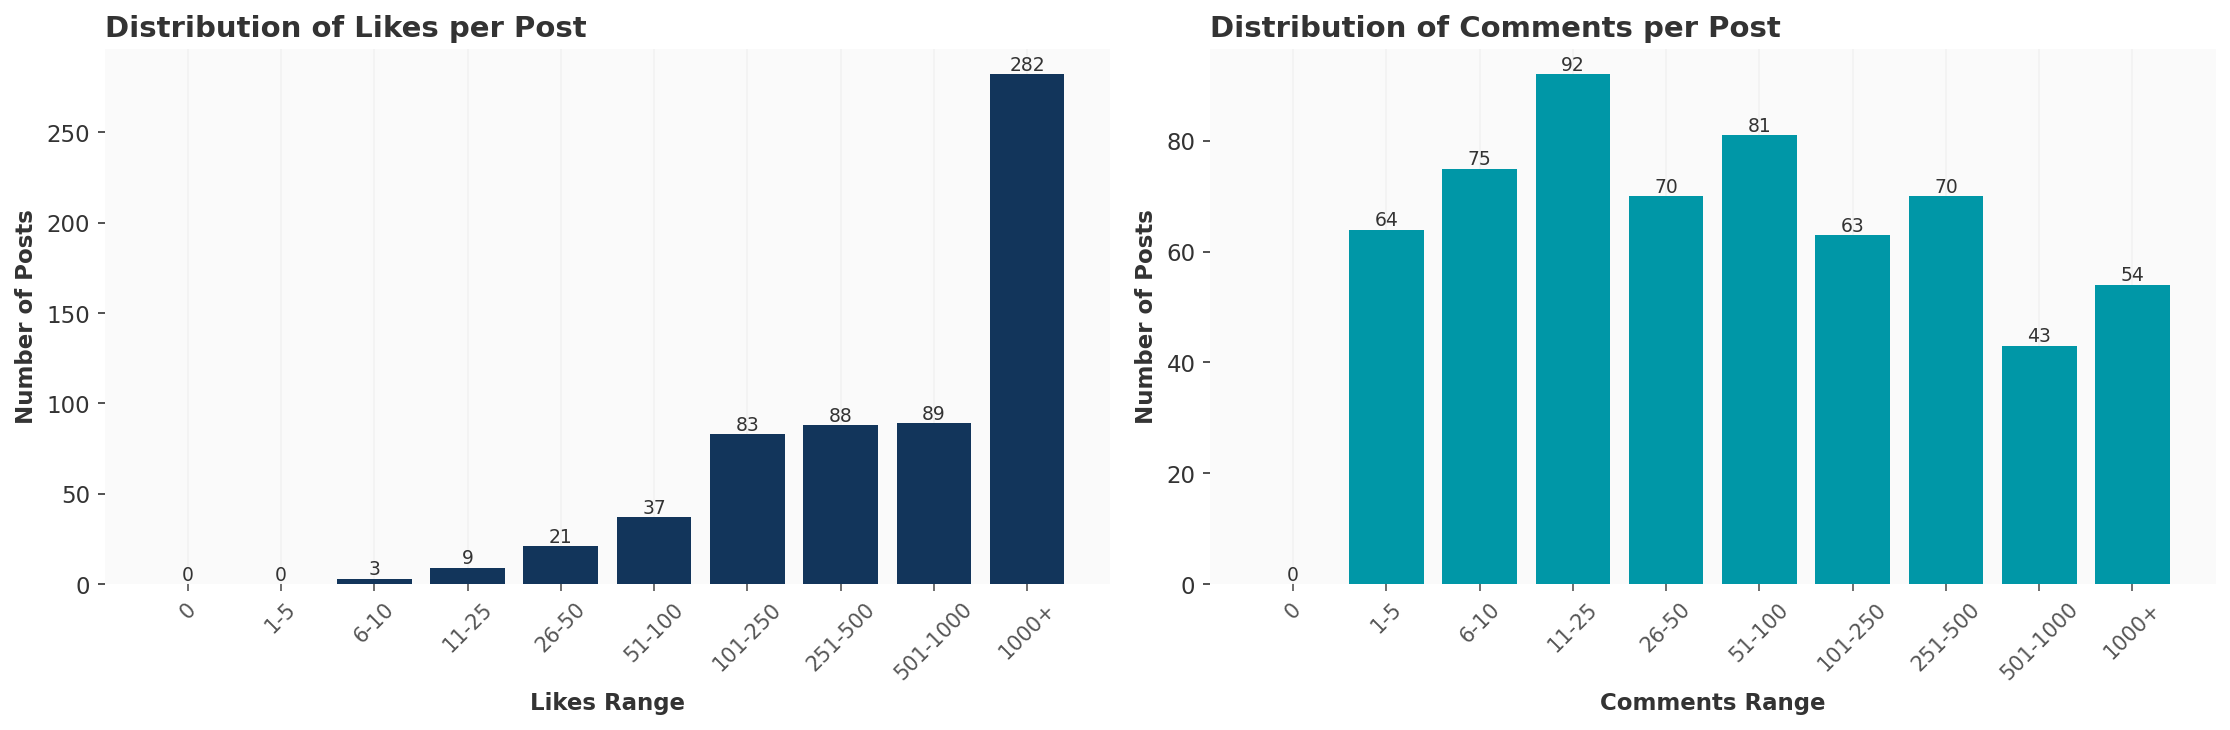

In [13]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


# =============================
# Load posts
# =============================
base = Path("/Users/shergoshami/Downloads/DATA")

# Same posts across folders
post_source = base / "male_prolife"


data = []

for file in post_source.glob("*.json"):

    with open(file, "r") as f:
        post = json.load(f)

    data.append({
        "Likes": post.get("post_total_likes", 0),
        "Comments": post.get("post_total_comments_count", 0)
    })


df = pd.DataFrame(data)



# =============================
# Style
# =============================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25
})


blue = "#12355B"
teal = "#0097A7"



# =============================
# Better engagement groups
# =============================

bins = [
    -1,
    0,
    5,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    float("inf")
]


labels = [
    "0",
    "1-5",
    "6-10",
    "11-25",
    "26-50",
    "51-100",
    "101-250",
    "251-500",
    "501-1000",
    "1000+"
]



likes_groups = pd.cut(
    df["Likes"],
    bins=bins,
    labels=labels
).value_counts().sort_index()


comments_groups = pd.cut(
    df["Comments"],
    bins=bins,
    labels=labels
).value_counts().sort_index()



# =============================
# Plot
# =============================

fig, ax = plt.subplots(
    1,
    2,
    figsize=(15,5),
    dpi=150
)



# Likes

bars1 = ax[0].bar(
    labels,
    likes_groups.values,
    color=blue
)

ax[0].set_title(
    "Distribution of Likes per Post",
    loc="left",
    fontweight="bold"
)

ax[0].set_xlabel(
    "Likes Range"
)

ax[0].set_ylabel(
    "Number of Posts"
)

ax[0].tick_params(
    axis="x",
    rotation=45
)



# Comments

bars2 = ax[1].bar(
    labels,
    comments_groups.values,
    color=teal
)

ax[1].set_title(
    "Distribution of Comments per Post",
    loc="left",
    fontweight="bold"
)

ax[1].set_xlabel(
    "Comments Range"
)

ax[1].set_ylabel(
    "Number of Posts"
)

ax[1].tick_params(
    axis="x",
    rotation=45
)



# Numbers above bars

for a in ax:
    for container in a.containers:
        a.bar_label(
            container,
            fontsize=9
        )
    a.grid(axis="y")



plt.tight_layout()

plt.show()

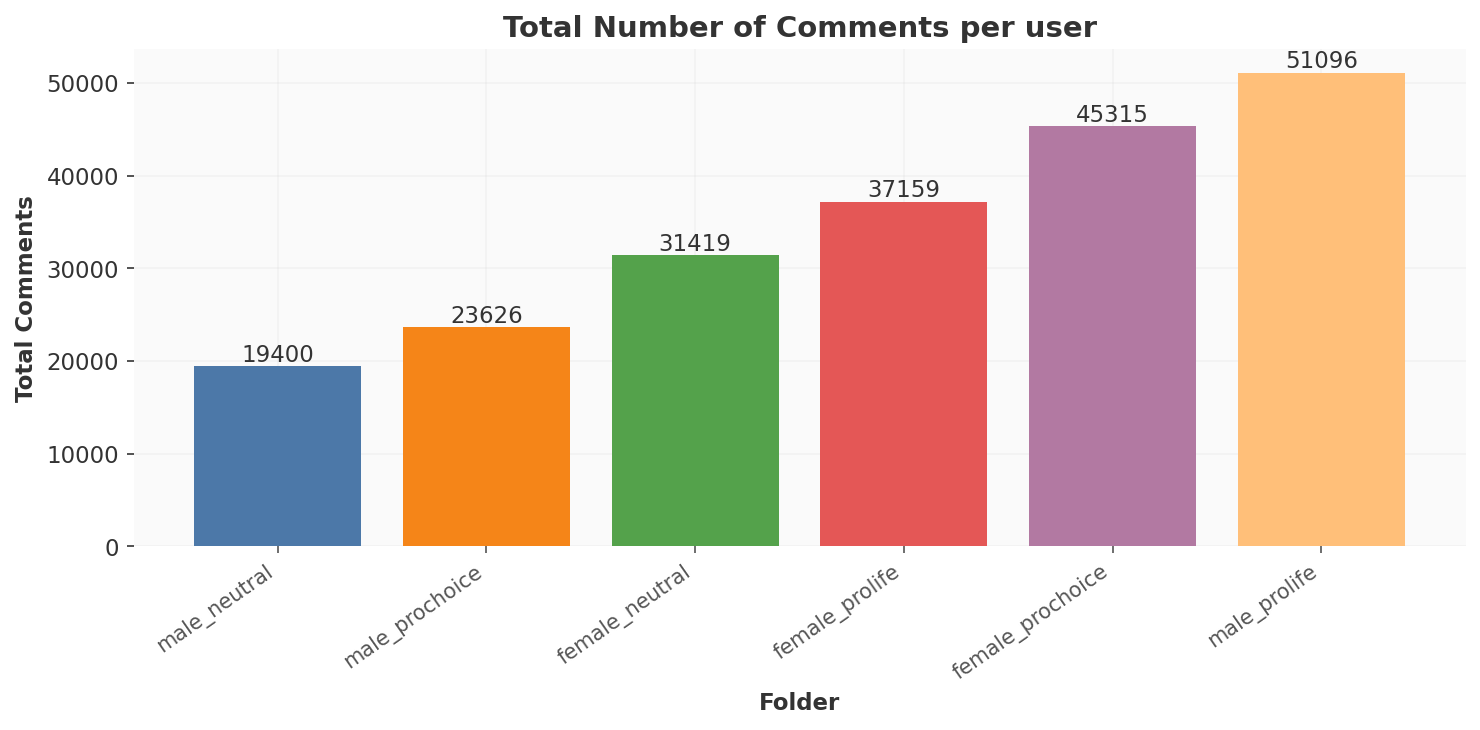

                  count    sum       mean  median   max
folder                                                 
male_prolife        612  51096  83.490196    15.0  1987
female_prochoice    612  45315  74.044118    14.0  2903
female_prolife      612  37159  60.717320    14.0  2383
female_neutral      612  31419  51.338235    13.0  1878
male_prochoice      612  23626  38.604575    13.0  1229
male_neutral        612  19400  31.699346    13.0   985


In [14]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

base = Path("/Users/shergoshami/Downloads/DATA")

folders = [
    "female_neutral",
    "female_prochoice",
    "female_prolife",
    "male_neutral",
    "male_prochoice",
    "male_prolife"
]

data = []

for folder in folders:
    for file in (base / folder).glob("*.json"):
        with open(file, "r") as f:
            post = json.load(f)

        data.append({
            "folder": folder,
            "comments": len(post.get("comments", []))
        })

df = pd.DataFrame(data)

# Total comments per folder
total = df.groupby("folder")["comments"].sum().sort_values()

# Plot
plt.figure(figsize=(10,5))

bars = plt.bar(
    total.index,
    total.values,
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
        "#B279A2",
        "#FFBF79"
    ]
)

plt.title("Total Number of Comments per user", fontsize=14, fontweight="bold")
plt.ylabel("Total Comments")
plt.xlabel("Folder")
plt.xticks(rotation=35, ha="right")

# values on bars
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# Statistical table
print(
    df.groupby("folder")["comments"]
      .agg(["count", "sum", "mean", "median", "max"])
      .sort_values("sum", ascending=False)
)


COMMENT AUTHOR VERIFICATION
Verified          Non-Verified  Verified  Total  Verified %  Non-Verified %
User Section                                                               
male_neutral             18846       554  19400        2.86           97.14
male_prochoice           23044       582  23626        2.46           97.54
female_neutral           30754       665  31419        2.12           97.88
female_prolife           36420       739  37159        1.99           98.01
female_prochoice         44414       901  45315        1.99           98.01
male_prolife             50156       940  51096        1.84           98.16


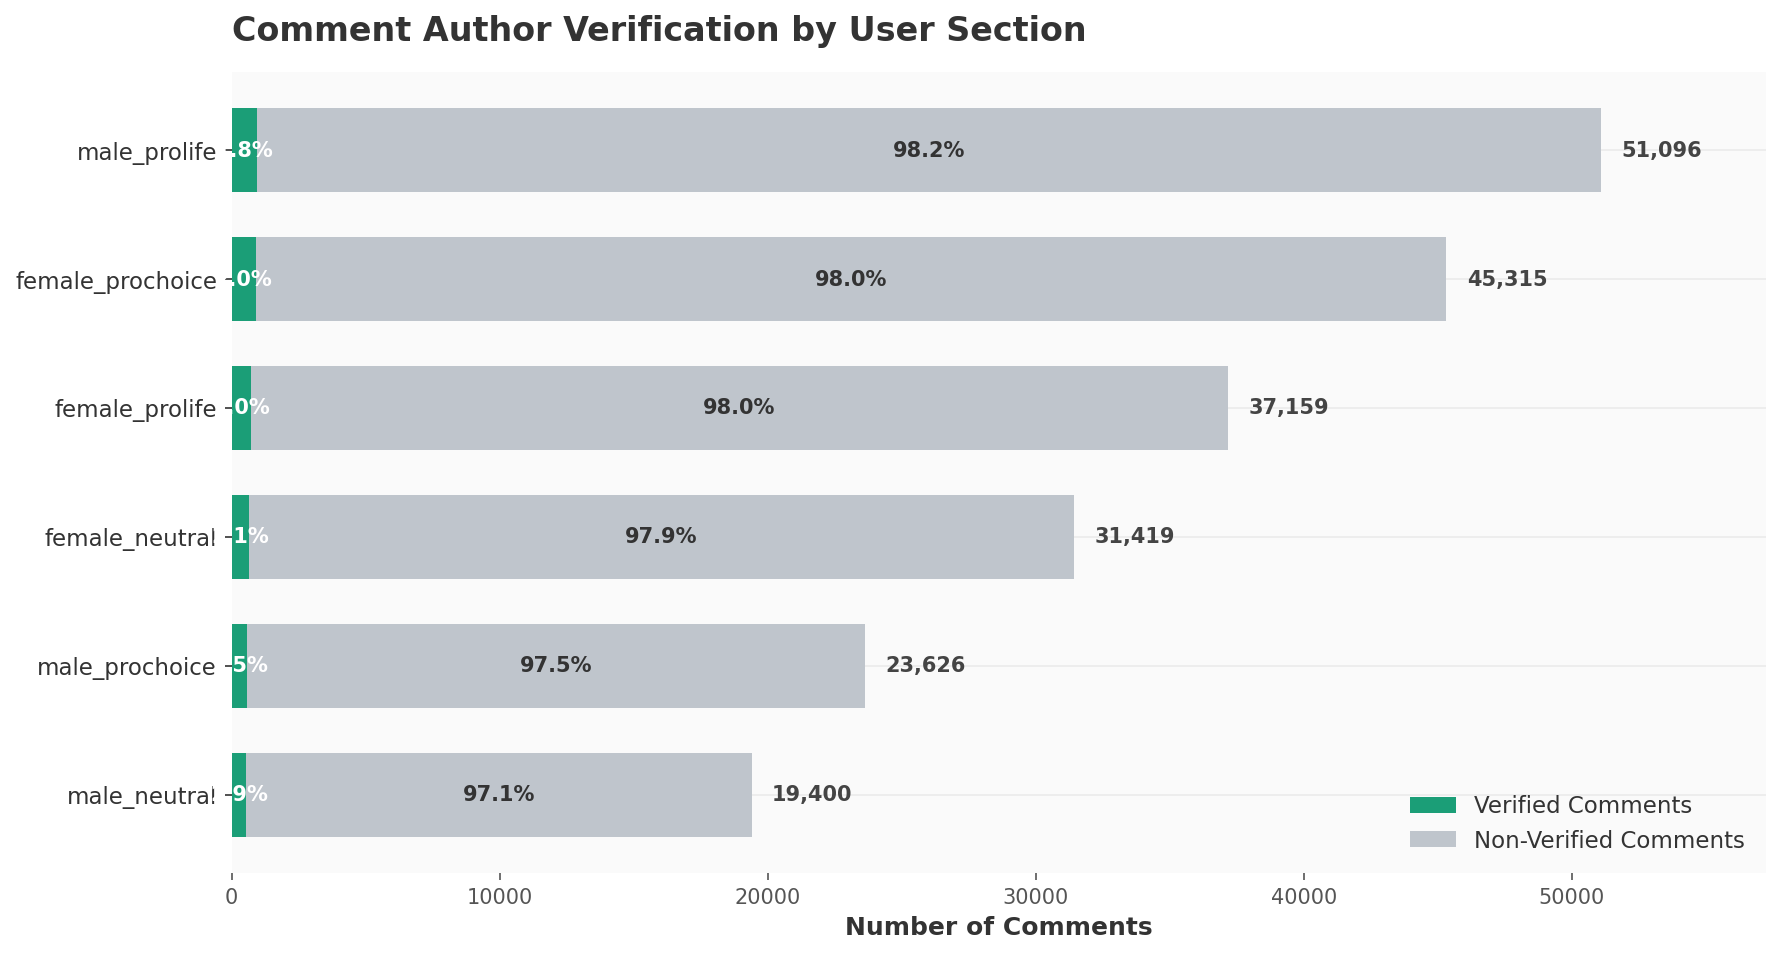


VERIFICATION RATE (%)
Verified          Verified %  Non-Verified %  Total
User Section                                       
male_neutral            2.86           97.14  19400
male_prochoice          2.46           97.54  23626
female_neutral          2.12           97.88  31419
female_prolife          1.99           98.01  37159
female_prochoice        1.99           98.01  45315
male_prolife            1.84           98.16  51096


In [15]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# =============================
# style
# =============================

plt.rcParams.update({

    # Typography
    "font.family": "DejaVu Sans",
    "font.size": 11,

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "bold",

    "xtick.labelsize": 10,
    "ytick.labelsize": 11,


    # Figure quality
    "figure.dpi": 150,
    "savefig.dpi": 300,

    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FAFAFA",


    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,


    # Grid
    "axes.grid": True,
    "axes.axisbelow": True,

    "grid.color": "#D9D9D9",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.45,


    # Colors
    "text.color": "#333333",
    "axes.labelcolor": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#333333",

    "patch.edgecolor": "none"
})



# =============================
# Dataset
# =============================

base = Path("/Users/shergoshami/Downloads/DATA")


folders = [
    "female_neutral",
    "female_prochoice",
    "female_prolife",
    "male_neutral",
    "male_prochoice",
    "male_prolife"
]


data = []



# =============================
# Extract comments
# =============================

for folder in folders:

    folder_path = base / folder

    if not folder_path.exists():
        continue


    for file in folder_path.glob("*.json"):

        with open(file, "r") as f:
            post = json.load(f)


        for comment in post.get("comments", []):

            data.append({

                "User Section": folder,

                "Verified": comment.get(
                    "is_verified",
                    False
                )

            })


df = pd.DataFrame(data)



# =============================
# Summary statistics
# =============================

summary = (
    df.groupby(
        [
            "User Section",
            "Verified"
        ]
    )
    .size()
    .unstack(fill_value=0)
)



summary = summary.rename(
    columns={
        True: "Verified",
        False: "Non-Verified"
    }
)





for col in [
    "Verified",
    "Non-Verified"
]:

    if col not in summary.columns:
        summary[col] = 0



# Total comments

summary["Total"] = (
    summary["Verified"]
    +
    summary["Non-Verified"]
)



# Percentages

summary["Verified %"] = (
    summary["Verified"]
    /
    summary["Total"]
    *
    100
)


summary["Non-Verified %"] = (
    summary["Non-Verified"]
    /
    summary["Total"]
    *
    100
)



# Sort :

summary = summary.sort_values(
    "Total",
    ascending=True
)



print("\nCOMMENT AUTHOR VERIFICATION")
print(summary.round(2))



# =============================
# Colors
# =============================

verified_color = "#1B9E77"

non_verified_color = "#BFC5CC"



# =============================
# Plot
# =============================

fig, ax = plt.subplots(
    figsize=(12, 6.5),
    dpi=150
)



y = np.arange(
    len(summary)
)



# Verified comments

ax.barh(
    y,
    summary["Verified"],
    color=verified_color,
    height=0.65,
    label="Verified Comments"
)



# Non verified comments

ax.barh(
    y,
    summary["Non-Verified"],
    left=summary["Verified"],
    color=non_verified_color,
    height=0.65,
    label="Non-Verified Comments"
)



# =============================
# Add labels
# =============================

max_total = summary["Total"].max()


for i, (_, row) in enumerate(summary.iterrows()):

    verified = row["Verified"]

    non_verified = row["Non-Verified"]

    verified_pct = row["Verified %"]

    non_verified_pct = row["Non-Verified %"]



    # Verified percentage

    if verified > 0:

        ax.text(
            verified / 2,
            i,
            f"{verified_pct:.1f}%",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )



    # Non verified percentage

    if non_verified > 0:

        ax.text(
            verified + non_verified / 2,
            i,
            f"{non_verified_pct:.1f}%",
            ha="center",
            va="center",
            color="#333333",
            fontsize=10,
            fontweight="bold"
        )



    # Total comments

    ax.text(
        verified + non_verified + max_total*0.015,
        i,
        f"{int(row['Total']):,}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#444444"
    )



# =============================
# Formatting
# =============================

ax.set_yticks(y)

ax.set_yticklabels(
    summary.index
)



ax.set_xlabel(
    "Number of Comments"
)



ax.set_title(
    "Comment Author Verification by User Section",
    loc="left",
    pad=15
)



ax.legend(
    frameon=False,
    loc="lower right"
)



ax.grid(
    axis="x"
)



# Remove unnecessary margins

ax.margins(
    x=0.12
)



plt.tight_layout()

plt.show()



# =============================
# Final table
# =============================

print("\nVERIFICATION RATE (%)")

print(
    summary[
        [
            "Verified %",
            "Non-Verified %",
            "Total"
        ]
    ]
    .round(2)
)